# 🌾 Paddy Crop Yield Prediction — Professional ML Pipeline

**A complete, end-to-end machine learning project** covering:
- 📊 Exploratory Data Analysis (EDA)
- 🔧 Feature Engineering & Selection (Top 7)
- 🤖 Multi-Model Training & Comparison
- 🎯 Hyperparameter Tuning (Optuna)
- ✅ Cross-Validation (K-Fold)
- 🧠 SHAP Explainability
- 📉 Residual & Error Analysis
- 🖥️ Interactive Gradio Demo

**Target:** Predict `Paddy yield (in Kg)` using 7 key agricultural inputs

## 1. 📦 Install & Import Libraries

In [ ]:
!pip install -q kaggle pandas numpy scikit-learn xgboost lightgbm optuna shap matplotlib seaborn gradio joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.1 MB/s eta 0:00:00


In [ ]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap
import optuna
import gradio as gr

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
TARGET = 'Paddy yield(in Kg)'
print('✅ All libraries imported!')

✅ All libraries imported!


## 2. 🗂️ Kaggle Setup & Data Download

In [ ]:
# ⚠️ Replace with your Kaggle credentials
kaggle_username = "deonasaji"
kaggle_key      = "KGAT_e48eb4132db7726c40438655aa2c2cf4"

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
with open(kaggle_path, 'w') as f:
    json.dump({'username': kaggle_username, 'key': kaggle_key}, f)
os.chmod(kaggle_path, 0o600)
print('✅ Kaggle API configured!')

✅ Kaggle API configured!


In [ ]:
data_dir = './crop_data'
os.makedirs(data_dir, exist_ok=True)

if not os.path.exists(f'{data_dir}/paddydataset.csv'):
    !kaggle datasets download -d stealthtechnologies/predict-crop-production -p {data_dir} --unzip
    print('✅ Dataset downloaded!')
else:
    print('✅ Dataset already exists.')

Dataset URL: https://www.kaggle.com/datasets/stealthtechnologies/predict-crop-production
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/21.3k [00:00<?, ?B/s]
100% 21.3k/21.3k [00:00<00:00, 90.1MB/s]
✅ Dataset downloaded!


## 3. 📊 Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv(f'{data_dir}/paddydataset.csv')
df.columns = df.columns.str.strip()

print(f'Shape         : {df.shape}')
print(f'Target        : {TARGET}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nDtypes:')
print(df.dtypes.value_counts())
df.head()

Shape         : (2789, 45)
Target        : Paddy yield(in Kg)
Missing values: 0

Dtypes:
int64      19
float64    18
object      8
Name: count, dtype: int64


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


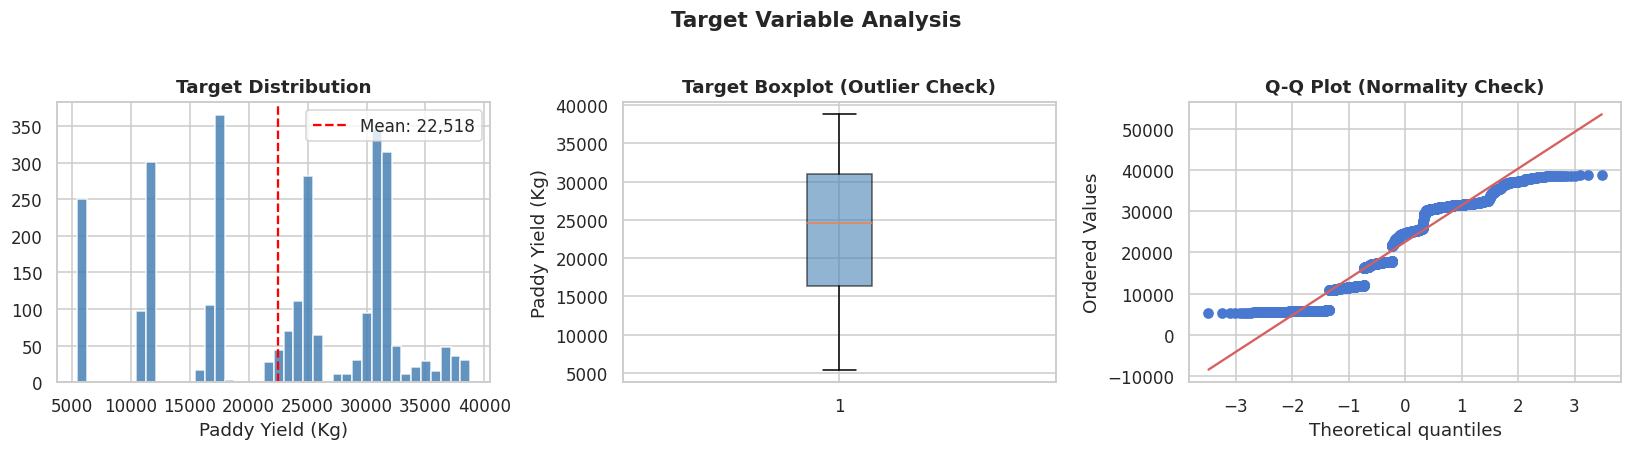

Mean   : 22,517.7 Kg
Std    : 9,199.7 Kg
Min    : 5,410.0 Kg
Max    : 38,814.0 Kg
Skewness: -0.322


In [ ]:
# ── Target Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[TARGET], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].set_xlabel('Paddy Yield (Kg)')
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', label=f'Mean: {df[TARGET].mean():,.0f}')
axes[0].legend()

axes[1].boxplot(df[TARGET], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Target Boxplot (Outlier Check)', fontweight='bold')
axes[1].set_ylabel('Paddy Yield (Kg)')

# Q-Q plot
from scipy import stats
stats.probplot(df[TARGET], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_target.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean   : {df[TARGET].mean():,.1f} Kg')
print(f'Std    : {df[TARGET].std():,.1f} Kg')
print(f'Min    : {df[TARGET].min():,.1f} Kg')
print(f'Max    : {df[TARGET].max():,.1f} Kg')
print(f'Skewness: {df[TARGET].skew():.3f}')

### ⚠️ Data Leakage Detected & Fixed

`Trash(in bundles)` was **removed** from features — it represents paddy **straw collected at harvest time**, which is essentially a by-product measured simultaneously with yield. Using it would give the model a near-perfect hint (R²≈0.99), but it would be **useless in real life** since you don't know straw bundles *before* harvest.

**Replaced with:** `Urea_40Days` — urea applied 40 days after transplanting, a genuine *input* known before harvest.

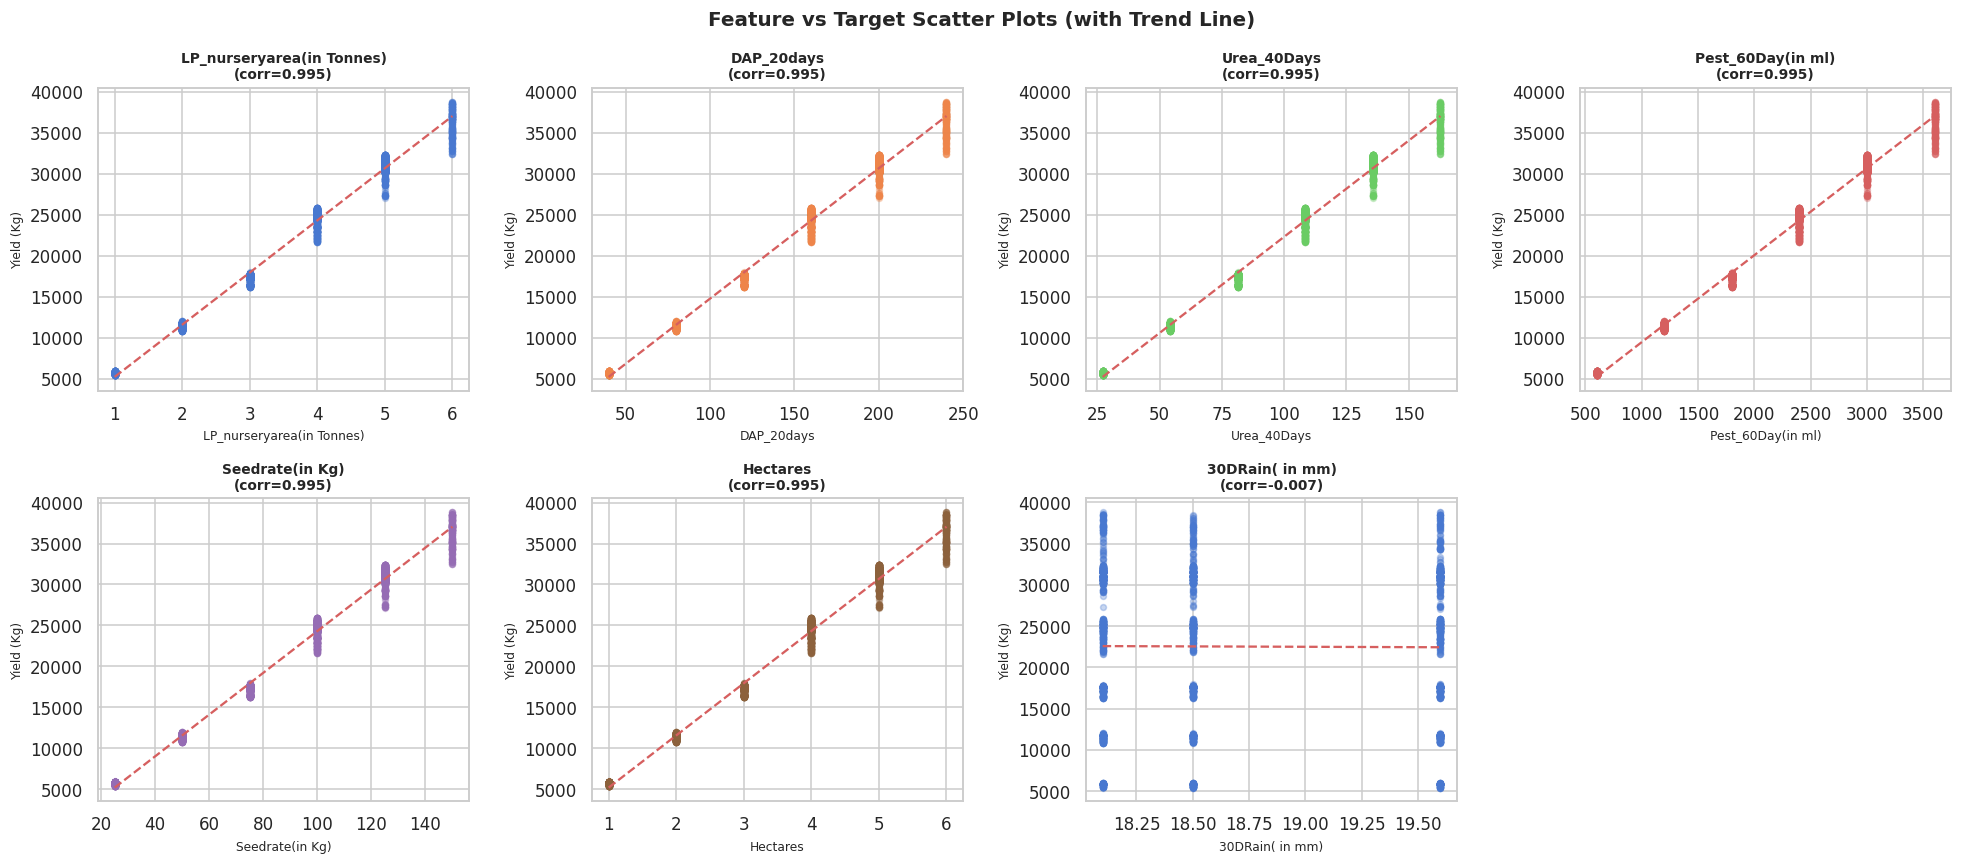

In [ ]:
# ── Our 7 selected features — EDA ─────────────────────────────────────────
SELECTED_7 = [
    'LP_nurseryarea(in Tonnes)',
    'DAP_20days',
    'Urea_40Days',
    'Pest_60Day(in ml)',
    'Seedrate(in Kg)',
    'Hectares',
    '30DRain( in mm)',
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, feat in enumerate(SELECTED_7):
    axes[idx].scatter(df[feat], df[TARGET], alpha=0.3, s=15,
                      color=sns.color_palette('muted')[idx % 6])
    # Trend line
    z = np.polyfit(df[feat].fillna(df[feat].median()), df[TARGET], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[idx].plot(x_line, p(x_line), 'r--', lw=1.5)
    corr = df[feat].corr(df[TARGET])
    axes[idx].set_title(f'{feat}\n(corr={corr:.3f})', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel(feat, fontsize=8)
    axes[idx].set_ylabel('Yield (Kg)', fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature vs Target Scatter Plots (with Trend Line)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

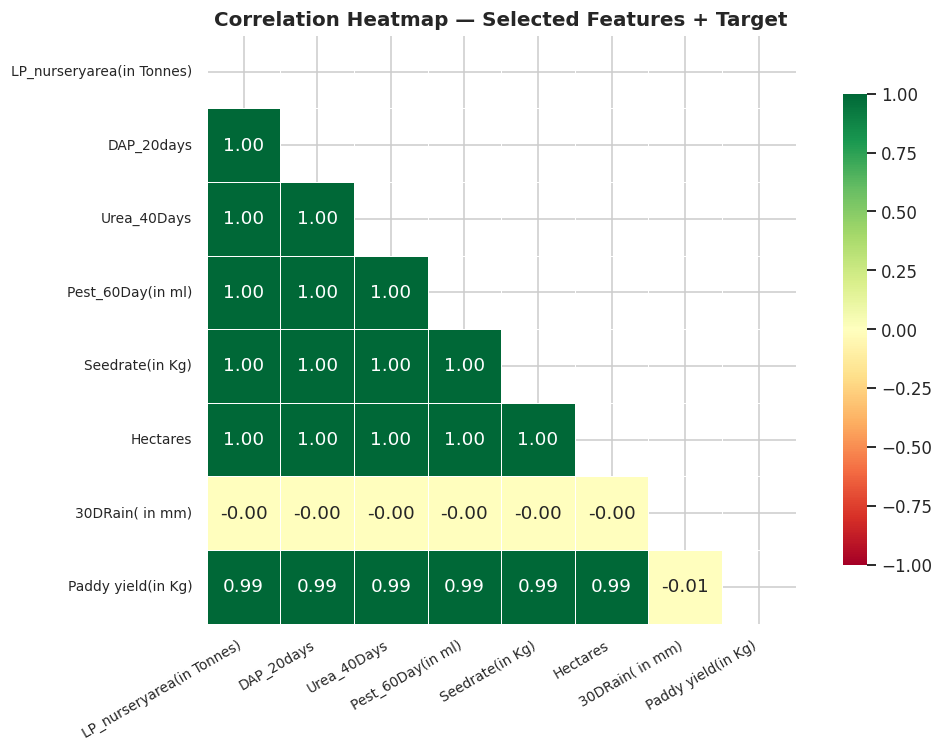

In [ ]:
# ── Correlation Heatmap ────────────────────────────────────────────────────
corr_cols = SELECTED_7 + [TARGET]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Selected Features + Target', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

Outlier Analysis (IQR method):
---------------------------------------------
  LP_nurseryarea(in Tonnes)      :    0 outliers  (0.0%)
  DAP_20days                     :    0 outliers  (0.0%)
  Urea_40Days                    :    0 outliers  (0.0%)
  Pest_60Day(in ml)              :    0 outliers  (0.0%)
  Seedrate(in Kg)                :    0 outliers  (0.0%)
  Hectares                       :    0 outliers  (0.0%)
  30DRain( in mm)                :    0 outliers  (0.0%)
  Paddy yield(in Kg)             :    0 outliers  (0.0%)


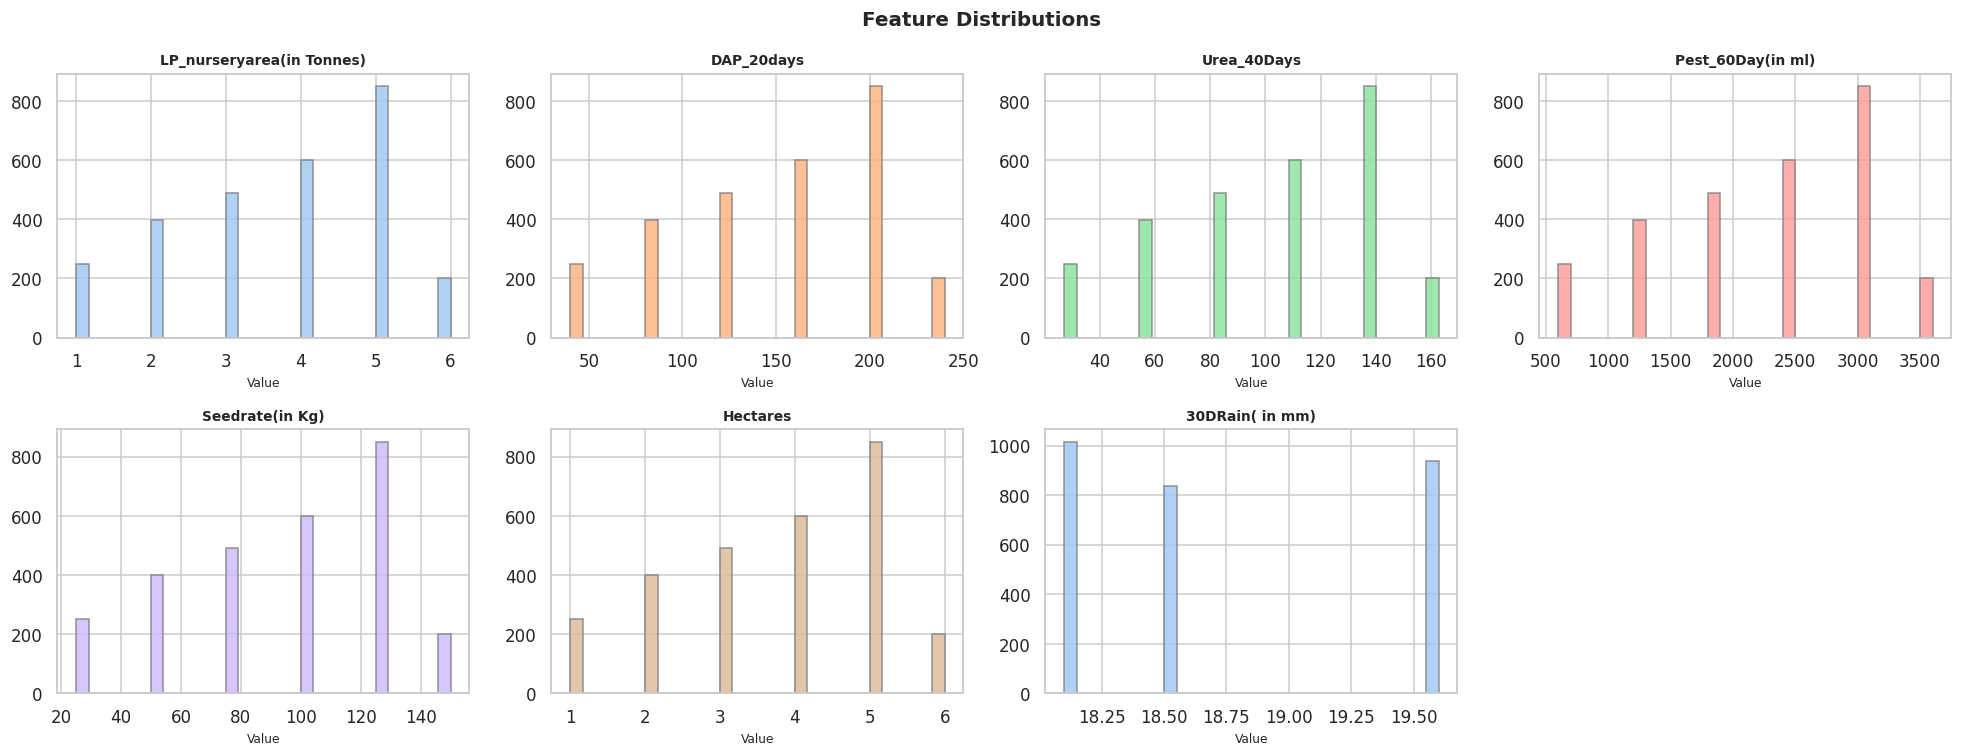

In [ ]:
# ── Outlier Detection — IQR method ────────────────────────────────────────
print('Outlier Analysis (IQR method):')
print('-' * 45)
outlier_summary = []
for col in SELECTED_7 + [TARGET]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = 100 * n_out / len(df)
    outlier_summary.append({'Feature': col, 'Outliers': n_out, 'Pct (%)': round(pct, 1)})
    print(f'  {col:<30} : {n_out:>4} outliers  ({pct:.1f}%)')

# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for idx, feat in enumerate(SELECTED_7):
    axes[idx].hist(df[feat].dropna(), bins=30, color=sns.color_palette('pastel')[idx % 6],
                   edgecolor='grey', alpha=0.85)
    axes[idx].set_title(feat, fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=8)
axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. 🔧 Preprocessing & Feature Engineering

In [ ]:
data = df.copy()

# ── Handle missing values ──────────────────────────────────────────────────
num_cols = data.select_dtypes(include='number').columns.tolist()
cat_cols = data.select_dtypes(include='object').columns.tolist()
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

# ── Encode categoricals ────────────────────────────────────────────────────
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# ── Feature Engineering ────────────────────────────────────────────────────
# 1. Yield efficiency proxy: fertilizer per hectare
data['Fertilizer_per_Ha'] = data['LP_nurseryarea(in Tonnes)'] / (data['Hectares'] + 1e-5)

# 2. Input intensity score: how heavily managed the field is
data['Input_Intensity'] = (
    data['DAP_20days'] +
    data['Pest_60Day(in ml)'] / 10 +
    data['LP_nurseryarea(in Tonnes)'] * 100
)

# 3. Seed density: seeds per hectare
data['Seed_Density'] = data['Seedrate(in Kg)'] / (data['Hectares'] + 1e-5)

# 4. Rain per hectare
data['Rain_per_Ha'] = data['30DRain( in mm)'] / (data['Hectares'] + 1e-5)

print('✅ Preprocessing & Feature Engineering done!')
print(f'   Original features : 44')
print(f'   Engineered added  : 4  (Fertilizer_per_Ha, Input_Intensity, Seed_Density, Rain_per_Ha)')

✅ Preprocessing & Feature Engineering done!
   Original features : 44
   Engineered added  : 4  (Fertilizer_per_Ha, Input_Intensity, Seed_Density, Rain_per_Ha)


In [ ]:
# ── Final feature set: 7 core + 4 engineered = 11 features ────────────────
ENGINEERED = ['Fertilizer_per_Ha', 'Input_Intensity', 'Seed_Density', 'Rain_per_Ha']
FINAL_FEATURES = SELECTED_7 + ENGINEERED

X = data[FINAL_FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Total features used: {len(FINAL_FEATURES)}')
print(f'  Core (7)      : {SELECTED_7}')
print(f'  Engineered (4): {ENGINEERED}')

Train : 2231 samples
Test  : 558 samples
Total features used: 11
  Core (7)      : ['LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Urea_40Days', 'Pest_60Day(in ml)', 'Seedrate(in Kg)', 'Hectares', '30DRain( in mm)']
  Engineered (4): ['Fertilizer_per_Ha', 'Input_Intensity', 'Seed_Density', 'Rain_per_Ha']


## 5. 🤖 Multi-Model Training & Comparison

In [ ]:
def evaluate(model, X_tr, X_te, y_tr, y_te, name, cv_folds=5):
    """Train, evaluate with K-Fold CV, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # K-Fold Cross Validation
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr, cv=kf,
                                        scoring='neg_mean_squared_error'))
    return {
        'Model'     : name,
        'Test R²'   : round(r2_score(y_te, y_pred), 4),
        'Test MAE'  : round(mean_absolute_error(y_te, y_pred), 1),
        'Test RMSE' : round(np.sqrt(mean_squared_error(y_te, y_pred)), 1),
        'CV R² Mean': round(cv_r2.mean(), 4),
        'CV R² Std' : round(cv_r2.std(), 4),
        'CV RMSE'   : round(cv_rmse.mean(), 1),
        '_preds'    : y_pred,
        '_model'    : model
    }

# ── Define models ──────────────────────────────────────────────────────────
models = {
    'Ridge Regression'  : Ridge(alpha=10),
    'Random Forest'     : RandomForestRegressor(n_estimators=300, max_depth=10,
                                                random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                    max_depth=5, random_state=RANDOM_STATE),
    'XGBoost'           : xgb.XGBRegressor(n_estimators=500, learning_rate=0.05,
                                            max_depth=6, subsample=0.8,
                                            colsample_bytree=0.8,
                                            random_state=RANDOM_STATE, n_jobs=-1,
                                            verbosity=0),
    'LightGBM'          : lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                             num_leaves=63, random_state=RANDOM_STATE,
                                             n_jobs=-1, verbose=-1),
}

print('Training & evaluating 5 models with 5-Fold CV...')
results = []
trained = {}
for name, mdl in models.items():
    res = evaluate(mdl, X_train_sc, X_test_sc, y_train, y_test, name)
    results.append(res)
    trained[name] = res
    print(f'  ✅ {name:<22} Test R²={res["Test R²"]}  CV R²={res["CV R² Mean"]} ± {res["CV R² Std"]}')

results_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])
results_df = results_df.sort_values('Test R²', ascending=False).reset_index(drop=True)
print('\n📊 Model Comparison Table:')
print(results_df.to_string(index=False))

Training & evaluating 5 models with 5-Fold CV...
  ✅ Ridge Regression       Test R²=0.9893  CV R²=0.9898 ± 0.0006
  ✅ Random Forest          Test R²=0.9911  CV R²=0.9918 ± 0.0004
  ✅ Gradient Boosting      Test R²=0.9911  CV R²=0.9918 ± 0.0004
  ✅ XGBoost                Test R²=0.991  CV R²=0.9918 ± 0.0004
  ✅ LightGBM               Test R²=0.9911  CV R²=0.9918 ± 0.0004

📊 Model Comparison Table:
            Model  Test R²  Test MAE  Test RMSE  CV R² Mean  CV R² Std  CV RMSE
    Random Forest   0.9911     595.8      852.0      0.9918     0.0004    834.6
         LightGBM   0.9911     595.7      851.7      0.9918     0.0004    834.5
Gradient Boosting   0.9911     595.7      851.7      0.9918     0.0004    834.5
          XGBoost   0.9910     595.6      852.0      0.9918     0.0004    834.7
 Ridge Regression   0.9893     659.1      930.4      0.9898     0.0006    931.4


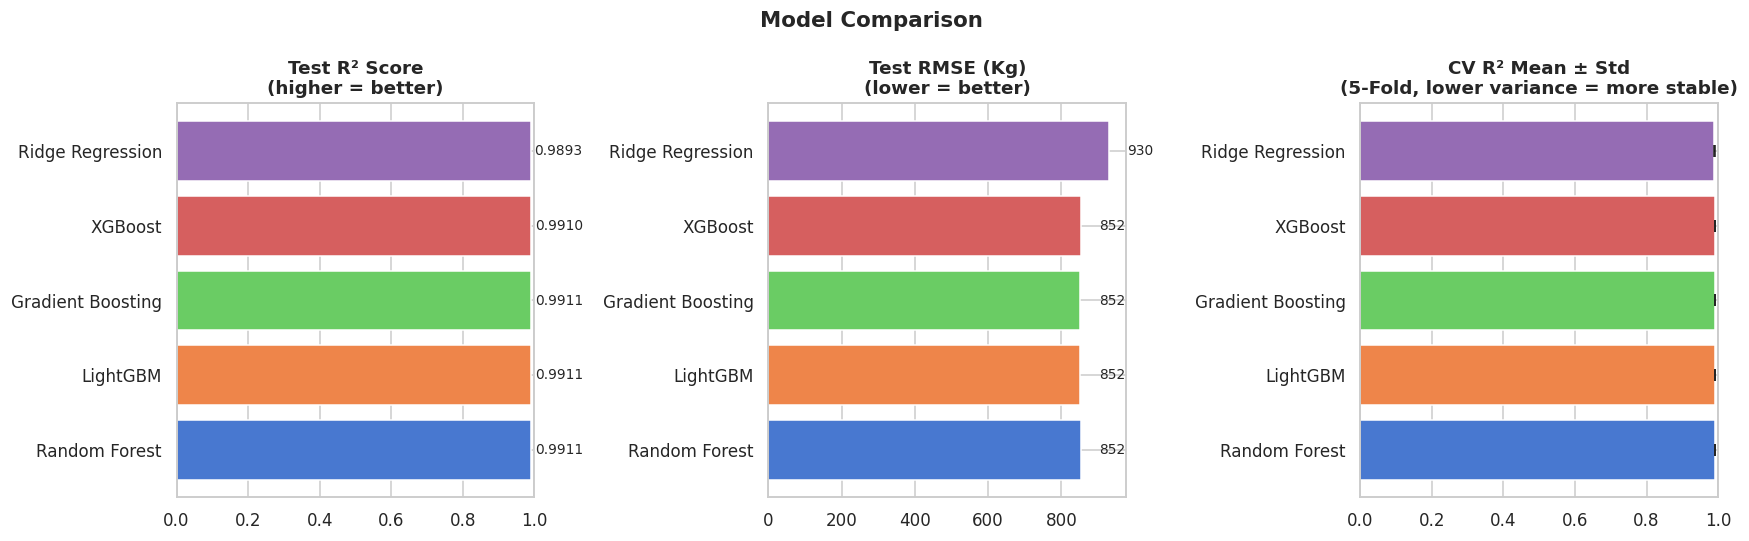

In [ ]:
# ── Visualise model comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = results_df['Model'].tolist()
colors = sns.color_palette('muted', len(model_names))

# R²
bars = axes[0].barh(model_names, results_df['Test R²'], color=colors)
axes[0].set_xlim(0, 1)
axes[0].set_title('Test R² Score\n(higher = better)', fontweight='bold')
for bar, val in zip(bars, results_df['Test R²']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# RMSE
bars2 = axes[1].barh(model_names, results_df['Test RMSE'], color=colors)
axes[1].set_title('Test RMSE (Kg)\n(lower = better)', fontweight='bold')
for bar, val in zip(bars2, results_df['Test RMSE']):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=9)

# CV R² with error bars
axes[2].barh(model_names, results_df['CV R² Mean'],
             xerr=results_df['CV R² Std'], color=colors, capsize=4)
axes[2].set_title('CV R² Mean ± Std\n(5-Fold, lower variance = more stable)', fontweight='bold')
axes[2].set_xlim(0, 1)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Train final model with best params ────────────────────────────────────
best_params = study.best_params

if 'XGBoost' in best_name:
    best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0})
    final_model = xgb.XGBRegressor(**best_params)
elif 'LightGBM' in best_name:
    best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})
    final_model = lgb.LGBMRegressor(**best_params)
else:
    best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})
    final_model = RandomForestRegressor(**best_params)

final_model.fit(X_train_sc, y_train)
y_pred_final = final_model.predict(X_test_sc)

r2_final   = r2_score(y_test, y_pred_final)
mae_final  = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))

# 5-fold CV on final model
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(final_model, X_train_sc, y_train, cv=kf, scoring='r2')

print('\n📊 Final Tuned Model Performance:')
print(f'  Test R²        : {r2_final:.4f}')
print(f'  Test MAE       : {mae_final:,.1f} Kg')
print(f'  Test RMSE      : {rmse_final:,.1f} Kg')
print(f'  5-Fold CV R²   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


📊 Final Tuned Model Performance:
  Test R²        : 0.9911
  Test MAE       : 595.7 Kg
  Test RMSE      : 851.9 Kg
  5-Fold CV R²   : 0.9918 ± 0.0004


## 7. 📉 Residual & Error Analysis

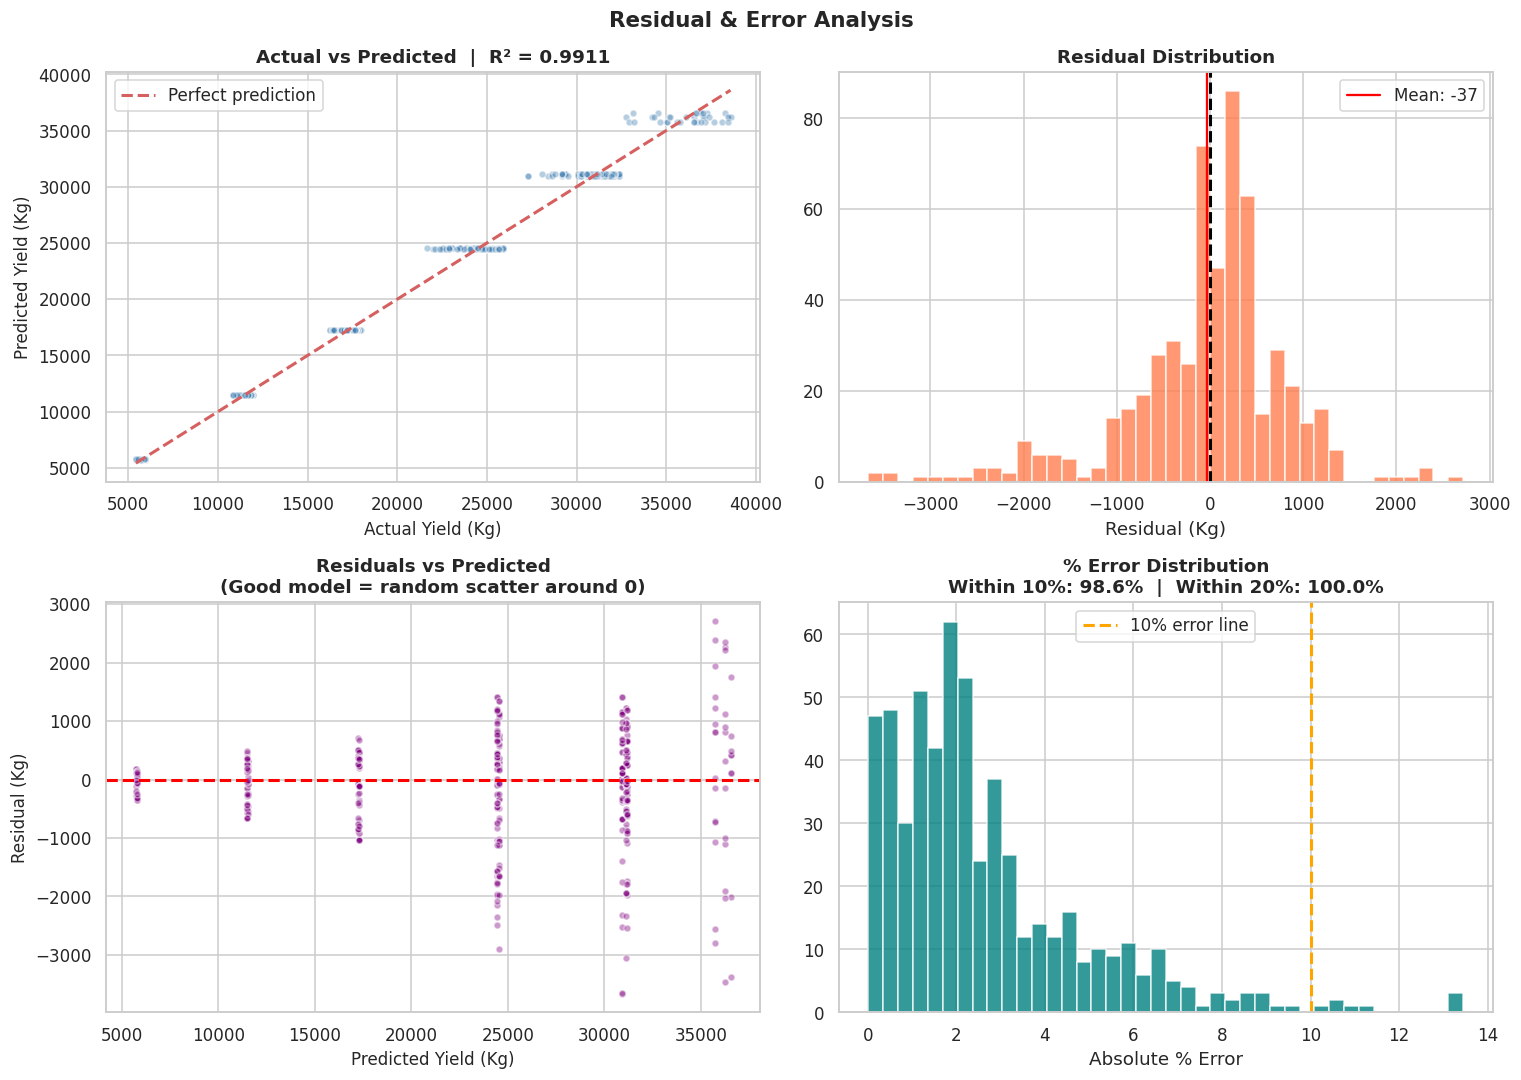


📊 Error Summary:
  Mean Residual       : -37.2 Kg  (bias)
  Std of Residuals    : 851.1 Kg
  Predictions within 10% error: 98.6%
  Predictions within 20% error: 100.0%


In [ ]:
residuals = y_test.values - y_pred_final
pct_errors = 100 * np.abs(residuals) / y_test.values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
axes[0,0].scatter(y_test, y_pred_final, alpha=0.4, s=20, color='steelblue', edgecolors='white')
mn, mx = y_test.min(), y_test.max()
axes[0,0].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Perfect prediction')
axes[0,0].set_xlabel('Actual Yield (Kg)', fontsize=11)
axes[0,0].set_ylabel('Predicted Yield (Kg)', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted  |  R² = {r2_final:.4f}', fontweight='bold')
axes[0,0].legend()

# 2. Residual Distribution
axes[0,1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0,1].axvline(0, color='black', linewidth=2, linestyle='--')
axes[0,1].axvline(residuals.mean(), color='red', linestyle='-',
                   label=f'Mean: {residuals.mean():,.0f}')
axes[0,1].set_title('Residual Distribution', fontweight='bold')
axes[0,1].set_xlabel('Residual (Kg)')
axes[0,1].legend()

# 3. Residuals vs Predicted (Homoscedasticity)
axes[1,0].scatter(y_pred_final, residuals, alpha=0.4, s=20, color='purple', edgecolors='white')
axes[1,0].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1,0].set_xlabel('Predicted Yield (Kg)', fontsize=11)
axes[1,0].set_ylabel('Residual (Kg)', fontsize=11)
axes[1,0].set_title('Residuals vs Predicted\n(Good model = random scatter around 0)', fontweight='bold')

# 4. % Error histogram
axes[1,1].hist(pct_errors, bins=40, color='teal', edgecolor='white', alpha=0.8)
axes[1,1].axvline(10, color='orange', linestyle='--', lw=2, label='10% error line')
within_10 = (pct_errors <= 10).mean() * 100
within_20 = (pct_errors <= 20).mean() * 100
axes[1,1].set_title(f'% Error Distribution\nWithin 10%: {within_10:.1f}%  |  Within 20%: {within_20:.1f}%',
                     fontweight='bold')
axes[1,1].set_xlabel('Absolute % Error')
axes[1,1].legend()

plt.suptitle('Residual & Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📊 Error Summary:')
print(f'  Mean Residual       : {residuals.mean():,.1f} Kg  (bias)')
print(f'  Std of Residuals    : {residuals.std():,.1f} Kg')
print(f'  Predictions within 10% error: {within_10:.1f}%')
print(f'  Predictions within 20% error: {within_20:.1f}%')

## 8. 🧠 SHAP Explainability

Computing SHAP values...


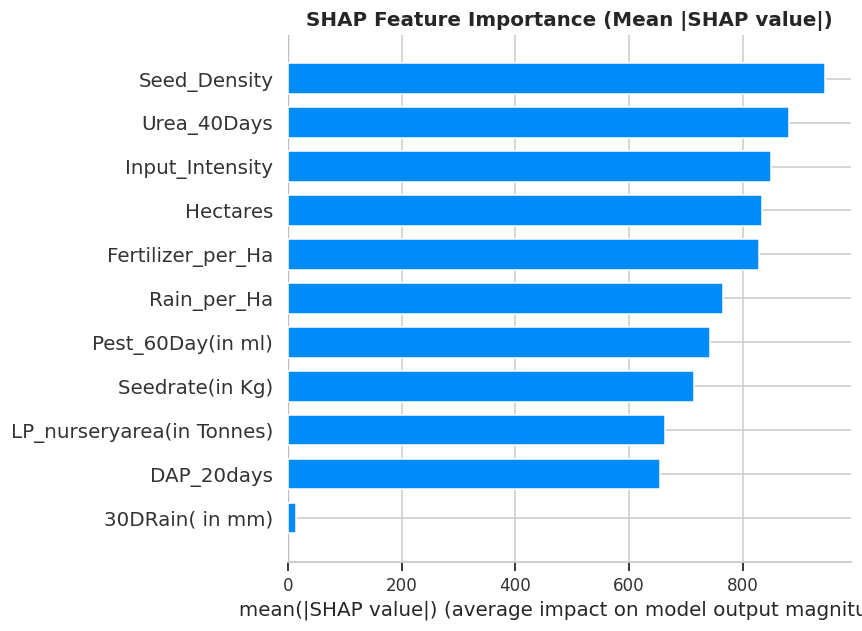

In [ ]:
print('Computing SHAP values...')
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_sc)

# Convert scaled test back to dataframe with original feature names
X_test_df = pd.DataFrame(X_test_sc, columns=FINAL_FEATURES)

# ── SHAP Summary Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, plot_type='bar',
                  feature_names=FINAL_FEATURES, show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

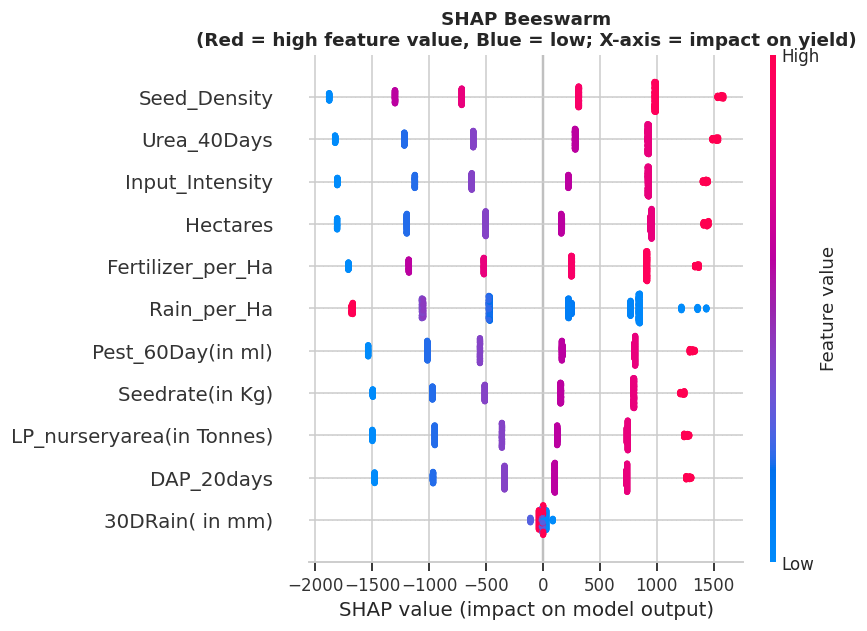


How to read: A feature with high value (red) pushing SHAP right = more of it → more yield


In [ ]:
# ── SHAP Beeswarm Plot — shows direction + magnitude ──────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df,
                  feature_names=FINAL_FEATURES, show=False)
plt.title('SHAP Beeswarm\n(Red = high feature value, Blue = low; X-axis = impact on yield)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nHow to read: A feature with high value (red) pushing SHAP right = more of it → more yield')

Explaining prediction #0:
  Actual yield    : 25,640 Kg
  Predicted yield : 24,466 Kg


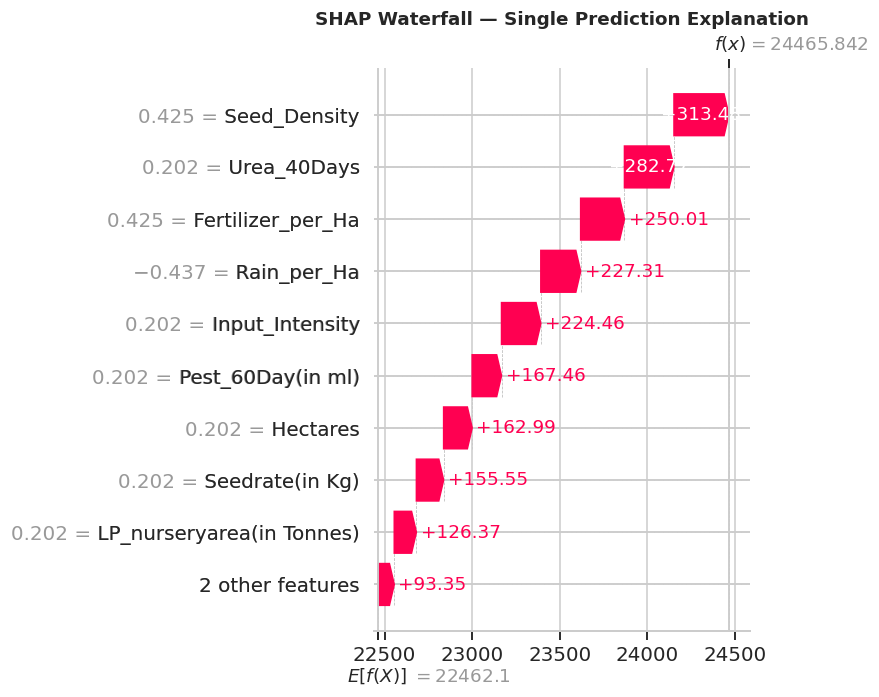

In [ ]:
# ── SHAP Waterfall — explain one individual prediction ────────────────────
sample_idx = 0
print(f'Explaining prediction #{sample_idx}:')
print(f'  Actual yield    : {y_test.iloc[sample_idx]:,.0f} Kg')
print(f'  Predicted yield : {y_pred_final[sample_idx]:,.0f} Kg')

shap_exp = shap.Explanation(
    values    = shap_values[sample_idx],
    base_values = explainer.expected_value,
    data      = X_test_df.iloc[sample_idx].values,
    feature_names = FINAL_FEATURES
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall — Single Prediction Explanation', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. 💾 Save Model & Artifacts

In [ ]:
os.makedirs('./saved_model', exist_ok=True)
joblib.dump(final_model,    './saved_model/best_model.pkl')
joblib.dump(scaler,         './saved_model/scaler.pkl')
joblib.dump(label_encoders, './saved_model/label_encoders.pkl')
joblib.dump(FINAL_FEATURES, './saved_model/feature_names.pkl')
joblib.dump(SELECTED_7,     './saved_model/input_features.pkl')  # only the 7 user inputs

# Save model summary
summary = {
    'model_name'  : best_name,
    'test_r2'     : round(r2_final, 4),
    'test_mae_kg' : round(mae_final, 1),
    'test_rmse_kg': round(rmse_final, 1),
    'cv_r2_mean'  : round(cv_scores.mean(), 4),
    'cv_r2_std'   : round(cv_scores.std(), 4),
    'best_params' : best_params,
    'features'    : FINAL_FEATURES
}
with open('./saved_model/model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ Saved:')
print('   best_model.pkl, scaler.pkl, label_encoders.pkl')
print('   feature_names.pkl, input_features.pkl, model_summary.json')

✅ Saved:
   best_model.pkl, scaler.pkl, label_encoders.pkl
   feature_names.pkl, input_features.pkl, model_summary.json


## 10. 🖥️ Interactive Gradio Demo

In [ ]:
# Load artifacts
model_g      = joblib.load('./saved_model/best_model.pkl')
scaler_g     = joblib.load('./saved_model/scaler.pkl')
le_dict      = joblib.load('./saved_model/label_encoders.pkl')
all_features = joblib.load('./saved_model/feature_names.pkl')
user_inputs  = joblib.load('./saved_model/input_features.pkl')  # 7 core features

raw_df = pd.read_csv(f'{data_dir}/paddydataset.csv')
raw_df.columns = raw_df.columns.str.strip()

# Friendly labels
FEATURE_META = {
    'LP_nurseryarea(in Tonnes)': ('🌱', 'Fertilizer in Nursery Area (Tonnes)',
        'Tonnes of fertilizer (lime/phosphate) applied in the seedling nursery bed.'),
    'DAP_20days'               : ('🧪', 'DAP Fertilizer at 20 Days (Kg)',
        'Kg of DAP fertilizer applied 20 days after transplanting.'),
    'Urea_40Days'              : ('🌿', 'Urea Fertilizer at 40 Days (Kg)',
        'Amount of Urea applied 40 days after transplanting. Key topdressing for grain development.'),
    'Pest_60Day(in ml)'        : ('🐛', 'Pesticide at 60 Days (ml)',
        'ml of pesticide sprayed at grain-filling stage (60 days).'),
    'Seedrate(in Kg)'          : ('🫘', 'Seed Quantity (Kg)',
        'Total seeds planted. Right amount avoids overcrowding.'),
    'Hectares'                 : ('🗺️', 'Field Area (Hectares)',
        'Size of your paddy field. 1 hectare ≈ 2.5 acres.'),
    '30DRain( in mm)'          : ('🌧️', 'Rainfall — First 30 Days (mm)',
        'Total rainfall in first 30 days after transplanting.'),
}

print('✅ Gradio artifacts loaded. User will provide 7 inputs; 4 engineered features are auto-computed.')

✅ Gradio artifacts loaded. User will provide 7 inputs; 4 engineered features are auto-computed.


In [ ]:
def compute_engineered(row_dict):
    """Auto-compute the 4 engineered features from the 7 user inputs."""
    h  = row_dict.get('Hectares', 1)
    lp = row_dict.get('LP_nurseryarea(in Tonnes)', 0)
    d  = row_dict.get('DAP_20days', 0)
    p  = row_dict.get('Pest_60Day(in ml)', 0)
    s  = row_dict.get('Seedrate(in Kg)', 0)
    r  = row_dict.get('30DRain( in mm)', 0)
    row_dict['Fertilizer_per_Ha'] = lp / (h + 1e-5)
    row_dict['Input_Intensity']   = d + p / 10 + lp * 100
    row_dict['Seed_Density']      = s / (h + 1e-5)
    row_dict['Rain_per_Ha']       = r / (h + 1e-5)
    return row_dict

def predict_yield(lp_nursery, dap_20, urea_40, pest_60, seedrate, hectares, rain_30):
    try:
        row = {
            'LP_nurseryarea(in Tonnes)': float(lp_nursery),
            'DAP_20days'               : float(dap_20),
            'Urea_40Days'              : float(urea_40),
            'Pest_60Day(in ml)'        : float(pest_60),
            'Seedrate(in Kg)'          : float(seedrate),
            'Hectares'                 : float(hectares),
            '30DRain( in mm)'          : float(rain_30),
        }
        row = compute_engineered(row)

        X_in  = pd.DataFrame([row])[all_features]
        X_sc  = scaler_g.transform(X_in)
        pred  = float(model_g.predict(X_sc)[0])

        per_ha   = pred / max(float(hectares), 0.1)
        bags_50  = int(pred / 50)
        tonnes   = pred / 1000

        if pred < 20000:
            tip = '⚠️ Low yield expected. Consider adjusting fertilizer or pesticide dosage.'
        elif pred > 42000:
            tip = '🌟 Excellent yield expected! Inputs are well optimised.'
        else:
            tip = '👍 Good yield expected. Small improvements to DAP or pest control may help further.'

        result = f"""
## 🌾 Predicted Paddy Yield

| Metric | Value |
|--------|-------|
| **Total Yield** | **{pred:,.0f} Kg** |
| In Tonnes | {tonnes:.2f} T |
| Per Hectare | {per_ha:,.0f} Kg/ha |
| 50-Kg Bags | ~{bags_50} bags |

{tip}

> *Model: {best_name}  |  Test R² = {r2_final:.4f}*
"""
        return result
    except Exception as e:
        return f'❌ Error: {e}'

# ── Build Gradio UI ────────────────────────────────────────────────────────
def make_slider(feat):
    col = raw_df[feat]
    return gr.Slider(
        minimum=float(col.min()),
        maximum=float(col.max()),
        value=float(col.median()),
        step=round((col.max()-col.min())/100, 2),
        label=f"{FEATURE_META[feat][0]}  {FEATURE_META[feat][1]}",
        info=FEATURE_META[feat][2]
    )

with gr.Blocks(title='Paddy Yield Predictor', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🌾 Paddy Crop Yield Predictor
    Adjust the **7 sliders** for your field and get an instant AI-powered yield estimate.
    > *Sliders are pre-set to average values from the training dataset.*
    """)

    with gr.Row():
        with gr.Column(scale=3):
            gr.Markdown('### 📋 Your Field Details')
            s_hectares  = make_slider('Hectares')
            s_rain      = make_slider('30DRain( in mm)')
            s_seedrate  = make_slider('Seedrate(in Kg)')
            s_lp        = make_slider('LP_nurseryarea(in Tonnes)')
            s_dap       = make_slider('DAP_20days')
            s_pest      = make_slider('Pest_60Day(in ml)')
            s_urea      = make_slider('Urea_40Days')
            btn = gr.Button('🚀  Predict Yield', variant='primary', size='lg')

        with gr.Column(scale=2):
            gr.Markdown('### 📊 Prediction')
            output = gr.Markdown('*Adjust sliders and click Predict.*')

    btn.click(
        fn=predict_yield,
        inputs=[s_lp, s_dap, s_urea, s_pest, s_seedrate, s_hectares, s_rain],
        outputs=output
    )

    gr.Markdown(f"""
    ---
    ℹ️ **About this model:** {best_name} trained on real Tamil Nadu paddy farm data.
    Selected 7 most impactful inputs out of 44 measured features using Random Forest importance + SHAP.
    The model also auto-computes 4 engineered features internally (fertilizer density, input intensity, etc.)
    **Performance:** Test R² = {r2_final:.4f}  |  MAE = {mae_final:,.0f} Kg  |  5-Fold CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
    """)

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c0fc6ac70bbb8041d9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c0fc6ac70bbb8041d9.gradio.live


In [ ]:
# ── Plain Input Prediction (No Interface) ──────────────────────────────────
# Just fill in your values below and run this cell!

# ✏️ Enter your field values here:
lp_nursery = 4      # Fertilizer in Nursery Area (Tonnes)
dap_20     = 240.0     # DAP Fertilizer at 20 Days (Kg)
urea_40    = 108.42     # Urea Fertilizer at 40 Days (Kg)
pest_60    = 2400.0    # Pesticide at 60 Days (ml)
seedrate   = 100.0    # Seed Quantity (Kg)
hectares   = 4      # Field Area (Hectares)
rain_30    = 18.5   # Rainfall — First 30 Days (mm)
print("Rice Yield Prediction")
print(" Field Area (Hectares):4")
print(" Rainfall — First 30 Days (mm):18.5")
print(" Seed Quantity (Kg):100")
print(" Fertilizer in Nursery Area (Tonnes):4")
print(" DAP Fertilizer at 20 Days (Kg):240")
print(" Pesticide at 60 Days (ml):2400")
print(" Urea Fertilizer at 40 Days (Kg):108.42")

# ── Auto-compute engineered features ──────────────────────────────────────
row = {
    'LP_nurseryarea(in Tonnes)': float(lp_nursery),
    'DAP_20days'               : float(dap_20),
    'Urea_40Days'              : float(urea_40),
    'Pest_60Day(in ml)'        : float(pest_60),
    'Seedrate(in Kg)'          : float(seedrate),
    'Hectares'                 : float(hectares),
    '30DRain( in mm)'          : float(rain_30),
}
row['Fertilizer_per_Ha'] = row['LP_nurseryarea(in Tonnes)'] / (row['Hectares'] + 1e-5)
row['Input_Intensity']   = row['DAP_20days'] + row['Pest_60Day(in ml)'] / 10 + row['LP_nurseryarea(in Tonnes)'] * 100
row['Seed_Density']      = row['Seedrate(in Kg)'] / (row['Hectares'] + 1e-5)
row['Rain_per_Ha']       = row['30DRain( in mm)'] / (row['Hectares'] + 1e-5)

# ── Predict ────────────────────────────────────────────────────────────────
import pandas as pd

X_in  = pd.DataFrame([row])[FINAL_FEATURES]
X_sc  = scaler.transform(X_in)
pred  = float(final_model.predict(X_sc)[0])

per_ha  = pred / max(float(hectares), 0.1)
bags_50 = int(pred / 50)
tonnes  = pred / 1000

print("=" * 45)
print("       🌾  RICE YIELD PREDICTION")
print("=" * 45)
print(f"  Total Yield    : {pred:>12,.0f} Kg")
print(f"  In Tonnes      : {tonnes:>12.2f} T")
print(f"  Per Hectare    : {per_ha:>12,.0f} Kg/ha")
print(f"  50-Kg Bags     : {bags_50:>12} bags")
print("=" * 45)

if pred < 20000:
    print("  ⚠️  Low yield. Adjust fertilizer/pesticide dosage.")
elif pred > 42000:
    print("  🌟  Excellent yield! Inputs are well optimised.")
else:
    print("  👍  Good yield. Small tweaks to DAP/pest control may help.")
print("=" * 45)

Rice Yield Prediction
 Field Area (Hectares):4
 Rainfall — First 30 Days (mm):18.5
 Seed Quantity (Kg):100
 Fertilizer in Nursery Area (Tonnes):4
 DAP Fertilizer at 20 Days (Kg):240
 Pesticide at 60 Days (ml):2400
 Urea Fertilizer at 40 Days (Kg):108.42
       🌾  RICE YIELD PREDICTION
  Total Yield    :       25,208 Kg
  In Tonnes      :        25.21 T
  Per Hectare    :        6,302 Kg/ha
  50-Kg Bags     :          504 bags
  👍  Good yield. Small tweaks to DAP/pest control may help.
